In [1]:
from imports import *

In [2]:
# GLOBAL PARAMETERS
today = datetime.now().strftime('%Y-%m-%d') # For printing/filenames
path = r'C:\Users\Farrukh\jupyter-Notebooks\STOCKS\ML_TP_SL_Figures' # CHECK THIS PATH / CREATE THE FOLDER
pdf_path = os.path.join(path, f'{today}_ML_TA_MultipleStocks.pdf')
pred_file = os.path.join(path, "tp_sl_daily.xlsx")

plt.rcParams['font.family'] = 'Segoe UI Emoji' # Matplotlib Font Family for windows.

##### STOCKS ##########
TICKERS = ["COIN", "TSLA", "GOOGL", "AMAT", "AAPL", "NKE", "CRM", "BABA", "XPEV", "NIO", "CPNG", "U", "UNH"]

##### CRYPTOS ##########
#TICKERS = ["BTC-USD","ETH-USD", "XRP-USD", "SOL-USD", "ADA-USD", "DOGE-USD", "LTC-USD", "BCH-USD"]

isStockCrypto = "CRYPTO"

if "BTC-USD" in TICKERS:
    isStockCrypto = "CRYPTO"
else:
    isStockCrypto = "STOCKS"

_Nr = 50 # Skip model if the length is this
YEARS_OF_DATA = 4
PROFIT_TARGET = 0.08
STOP_LOSS = 0.08
_DAYS = 20 # Used for SMA and training
_FWDAYS = 14 # Forward days to plot stored data
windows = [3, 5, 7, 9, 13, 15, 19, 29, 39, 49, 59] # For calculating returns
_window = 9  # Backtesting
tolerance = 1.07
_FIBS = False
_FibLen = 20 # Scan pivots for fibonacci levels
_ms = 5 # global marker size for matplotlib

bold = '\033[1m'
end = '\033[0m'

# Time window
end_date = datetime.now()
start_date = end_date - timedelta(days=365 * YEARS_OF_DATA)

# Shared model components

FEATURES = [
    # Technical Indicators
    'RSI', 'RSI_SMA', 'CCI', '+DI', '-DI', 'ADX', 'ATR', 'VI+', 'KCu', 'KCl', 'Kasym', 'Kcount', 'STu', 'STl',

    # Moving Averages & Bands
    'SMA1', 'SMA2', 'SMA3', 'SMA_Ratio', 'Upper_Band', 'Lower_Band', 'Volume_MA20', 'SMIIO', 'SMIIO_Signal', 'SMIIO_Osc', 'MACD', 'Signal_Line',

    # Returns & Volatility
    'return1', 'return2', 'return3', 'Volatility', 'Scaled_Volatility', 'DD',

    # Volume Features
    'sumBuyVol', 'sumSellVol', 'vSpike', 'VPT', 'OBV', 'MFI', 'VWMA', 'CMF',

    # Candlestick Patterns
    'Candlesticks', 'gapStrength',

    # Market Sentiment & Signals
    'Bear', 'Bull', 'Neutral', 'StrongBull', 'StrongBear', 'Neutral', 'Exhaustion',

    # PIVOTS
    'PP_Avg', 'R1_Avg', 'R2_Avg', 'S1_Avg', 'S2_Avg'
]

results = []

In [3]:
# Functions
def get_stock_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date + timedelta(days=1), 
                     interval='1d', auto_adjust=False, progress=False)
    if df.empty:
        return None  # Explicitly return None if no data
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    df = df.dropna()  # Assign back the dropped NA rows
    if df.empty:
        print(f"No data for {ticker}, skipping.")
        return None
    return df

def get_fundamentals(ticker: str, df=None):
    stock = yf.Ticker(ticker)
    info = stock.info
    
    atr_value = None
    if df is not None and 'ATR' in df.columns:
        atr_value = f"${df['ATR'].iloc[-1]:.2f}"

    fundamentals = {}
    if atr_value is not None:
        fundamentals['ATR'] = atr_value

    fundamentals.update({
            'Market Cap': info.get('marketCap', 'N/A'),
            'Net Profit Margin': info.get('netMargins', 'N/A'),
            'PE Ratio': info.get('trailingPE', 'N/A'),
            'Quick Ratio': info.get('quickRatio', 'N/A'),
            'Long Term Debt': info.get('longTermDebt', 'N/A'),
            'Free Cash Flow': info.get('freeCashflow', 'N/A')
        })
    
    # Format numeric values for better readability
    def fmt(value):
        if isinstance(value, (int, float)) and value != 'N/A':
            if abs(value) > 1e9:
                return f"{value/1e9:.2f}B"
            elif abs(value) > 1e6:
                return f"{value/1e6:.2f}M"
            elif abs(value) > 1e3:
                return f"{value/1e3:.0f}K"
            else:
                return f"{value:.2f}"
        return value
    
    return {k: fmt(v) for k, v in fundamentals.items()}

def add_fundamentals_table(ax, fundamentals, loc='upper left', alpha=0.4):
    # Prepare data: rows = one column headers + all rows
    col_labels = ['Metric', 'Value']
    cell_text = [[k, v] for k, v in fundamentals.items()]

    # Choose bbox location in axes coordinates (x0, y0, width, height)
    # Tune these numbers to position nicely
    bbox_dict = {
        'upper left': [0.01, 0.95, 0.3, 0.25],
        'upper right': [0.68, 0.95, 0.3, 0.25],
        'lower left': [0.01, 0.05, 0.3, 0.25],
        'lower right': [0.68, 0.05, 0.3, 0.25]
    }
    bbox = bbox_dict.get(loc, [0.02, 0.95, 0.3, 0.25])

    # Build cell colours with alpha transparency
    base_color = [1, 1, 1, alpha]  # white with alpha
    header_color = [0.8, 0.8, 0.8, alpha]  # light gray with alpha

    cell_colours = [  # One row per data row (no header here)
        [base_color, base_color] for _ in cell_text
    ]

    # Insert header background colors (first row does not exist here, colLabels handled separately)

    # Add the table to the axes
    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='left',
        colLoc='left',
        colWidths=[0.4, 0.6],
        bbox=bbox,
        cellColours=cell_colours,
        edges='open'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(6)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell._loc = 'center'   # <- this line centers the header text
            cell.set_text_props(weight='bold')
            cell.set_facecolor(header_color)
        else:
            cell.set_edgecolor('none')

    return table

def add_technical_indicators(df):
    df['SMA1'] = df['Close'].rolling(window=int(_DAYS*0.5)).mean()
    df['SMA2'] = df['Close'].rolling(window=_DAYS).mean()
    df['SMA3'] = df['Close'].rolling(window=int(_DAYS*2)).mean()
    df['SMA_Ratio'] = df['SMA1'] / df['SMA2']
        
    df['ATR'] = ta.calculate_atr(high=df.High, low=df.Low, close=df.Close)
    df = ta.scaled_volatility(df)
    df = ta.add_candlestickpatterns(df)

    df['RSI']= ta.calculate_rsi(df)
    df['RSI_SMA'] = df['RSI'].rolling(14).mean()

    #Avoid overlap by using > function instead of >=
    bull = (df['Close'] > df['SMA2']) & (df['RSI'] >= 52) & (df['RSI'] > df['RSI_SMA'])
    bear = (df['Close'] < df['SMA2']) & (df['RSI'] <= 42) & (df['RSI'] < df['RSI_SMA'])
    
    # Identify overlap rows (both True)
    overlap = bull & bear
    
    # Clear overlap from bull and bear
    bull = bull & ~overlap
    bear = bear & ~overlap
    
    # Neutral covers either where neither bull nor bear is True or where overlap was
    neutral = ~(bull | bear) | overlap
    
    df['Bull'] = bull.astype(int)
    df['Bear'] = bear.astype(int)
    df['Neutral'] = neutral.astype(int)

    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=24, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['SMIIO'], df['SMIIO_Signal'], df['SMIIO_Osc'] = ta.calculate_smiio(df)

    df['Upper_Band'] = df['SMA1'] + (2 * df['Close'].rolling(20).std())
    df['Lower_Band'] = df['SMA1'] - (2 * df['Close'].rolling(20).std())
    df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
    df['buy_volume'] = (df.Close > df.Close.shift(1)) * df['Volume']
    df['sell_volume'] = (df.Close < df.Close.shift(1)) * df['Volume']
    df['sumBuyVol'] = df['buy_volume'].rolling(window=9).sum()
    df['sumSellVol'] = df['sell_volume'].rolling(window=9).sum()
    df['vSpike'] = np.where(df['Volume'] > 2 * df['Volume_MA20'],
                        np.where(df['Close'] > df['Open'], 1, -1), 0)
    df['VPT'] = df['Volume'].mul((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1)).cumsum()
    
    df['MFI'] = ta.calculate_mfi(df)
    df['CMF'] = ta.chaikin_money_flow(df, window=20)
    df['CCI'] = ta.calculate_cci(df)
    df['OBV'] = ta.calculate_obv(df)
    df[['+DI', '-DI', 'ADX']] = ta.calculate_dmi(df, n=14)

    
    df['VWMA'] = ta.calculate_vwma(df)
    df[['KCm', 'KCu', 'KCl', 'Kasym', 'Kcount']] = ta.calculate_keltner(df)
    df[['VI+', 'VI-']] = ta.calculate_vortex(df)
    df[['STu', 'STl']] = ta.calculate_supertrend(df)
    
    df['DD'] = df['Close'].where(df['Close'] < df['Close'].shift(1)).std()

    df['return1'] = df['Close'].pct_change(7)
    df['return2'] = df['Close'].pct_change(14)
    df['return3'] = df['Close'].pct_change(21)
    
    df['Volatility'] = df['Close'].rolling(14).std()

    strongbull_condition = ((df['RSI'] > 52) & (df['ADX'] > 22) & 
                           (df['+DI'] > df['-DI']) & (df['sumBuyVol'] > df['sumSellVol']))
    strongbear_condition = ((df['RSI'] < 40) & (df['ADX'] > 22) & 
                           (df['+DI'] < df['-DI']) & (df['sumBuyVol'] < df['sumSellVol']))
    
    overlap = strongbull_condition & strongbear_condition
    strongbull_condition = strongbull_condition & ~overlap
    strongbear_condition = strongbear_condition & ~overlap
    neutral_condition = ~(strongbull_condition | strongbear_condition) | overlap
    
    df['StrongBull'] = strongbull_condition.astype(int)
    df['StrongBear'] = strongbear_condition.astype(int)
    df['Neutral'] = neutral_condition.astype(int)

    df['gapStrength'] = ta.compute_gapStrength(df)
    df = ta.add_exhaustion_indicator(df)

    return df

def add_pivot_levels(df, window=_DAYS):
    # Compute rolling high/low/close over the window
    high = df['High'].rolling(window)
    low = df['Low'].rolling(window)
    close = df['Close'].rolling(window)
    # Classic floor trader pivots (you can adjust formulas as needed)
    PP = (high.max() + low.min() + close.apply(lambda x: x[-1])).div(3)
    R1 = 2 * PP - low.min()
    S1 = 2 * PP - high.max()
    R2 = PP + (high.max() - low.min())
    S2 = PP - (high.max() - low.min())
    # Assign to DataFrame
    df['PP'] = PP.fillna(method='bfill')
    df['R1'] = R1.fillna(method='bfill')
    df['S1'] = S1.fillna(method='bfill')
    df['R2'] = R2.fillna(method='bfill')
    df['S2'] = S2.fillna(method='bfill')
    return df

def add_pivots(df, win=windows):
    for w in win:
        roll_high = df['High'].rolling(w)
        roll_low = df['Low'].rolling(w)
        roll_close = df['Close'].rolling(w)
        # Calculate rolling pivots
        PP = (roll_high.max() + roll_low.min() + roll_close.apply(lambda x: x[-1])).div(3)
        R1 = 2 * PP - roll_low.min()
        S1 = 2 * PP - roll_high.max()
        R2 = PP + (roll_high.max() - roll_low.min())
        S2 = PP - (roll_high.max() - roll_low.min())
        # Store in DataFrame
        df[f'PP_{w}'] = PP
        df[f'R1_{w}'] = R1
        df[f'S1_{w}'] = S1
        df[f'R2_{w}'] = R2
        df[f'S2_{w}'] = S2
    return df

def average_pivots(df, windows=[5, 10, 14, 20]):
    for level in ['PP', 'R1', 'S1', 'R2', 'S2']:
        cols = [f'{level}_{w}' for w in windows]
        # Take row-wise mean, ignore NaN for early rows
        df[f'{level}_Avg'] = df[cols].mean(axis=1)
    return df
    
def compute_expected_return(df, forward_window=14, r_cols=['R1', 'R2']):
    df['Expected_Return'] = np.nan
    close_prices = df['Close'].values
    
    # Pre-extract pivot arrays
    pivot_arrays = []
    for col in r_cols:
        if col in df.columns:
            pivot_arrays.append(df[col].values)
        else:
            pivot_arrays.append(np.full(len(df), np.nan))
    
    for i in range(len(df) - forward_window):
        current_price = close_prices[i]
        
        # Gather valid pivot values for this row
        pivots = [arr[i] for arr in pivot_arrays if not np.isnan(arr[i])]
        target_level = max(pivots) if pivots else None
        
        future_window = close_prices[i+1:i+1+forward_window]
        
        if target_level is not None:
            # Check if future price hits the pivot level
            hit = False
            for future_price in future_window:
                if future_price >= target_level:
                    df.iloc[i, df.columns.get_loc('Expected_Return')] = (target_level - current_price) / current_price
                    hit = True
                    break
            if not hit and future_window.size > 0:
                df.iloc[i, df.columns.get_loc('Expected_Return')] = (np.nanmax(future_window) - current_price) / current_price
        else:
            if future_window.size > 0:
                df.iloc[i, df.columns.get_loc('Expected_Return')] = (np.nanmax(future_window) - current_price) / current_price
            else:
                df.iloc[i, df.columns.get_loc('Expected_Return')] = np.nan
    return df

def compute_expected_loss(df, forward_window=14, s_cols=['S1', 'S2']):
    df['Expected_Loss'] = np.nan
    close_prices = df['Close'].values
    
    pivot_arrays = []
    for col in s_cols:
        if col in df.columns:
            pivot_arrays.append(df[col].values)
        else:
            pivot_arrays.append(np.full(len(df), np.nan))
    
    for i in range(len(df) - forward_window):
        current_price = close_prices[i]
        
        pivots = [arr[i] for arr in pivot_arrays if not np.isnan(arr[i])]
        target_level = min(pivots) if pivots else None
        
        future_window = close_prices[i+1:i+1+forward_window]
        
        if target_level is not None:
            hit = False
            for future_price in future_window:
                if future_price <= target_level:
                    df.iloc[i, df.columns.get_loc('Expected_Loss')] = (target_level - current_price) / current_price
                    hit = True
                    break
            if not hit and future_window.size > 0:
                df.iloc[i, df.columns.get_loc('Expected_Loss')] = (np.nanmin(future_window) - current_price) / current_price
        else:
            if future_window.size > 0:
                df.iloc[i, df.columns.get_loc('Expected_Loss')] = (np.nanmin(future_window) - current_price) / current_price
            else:
                df.iloc[i, df.columns.get_loc('Expected_Loss')] = np.nan
    return df


def initialize_XGBR():
    model = XGBRegressor(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
    return model

def label_hit2(df, window=14, profit_target=0.07, stop_loss=0.07):
    # Ensure Bull/Bear columns have no NaNs and are integers or floats
    df['Bull'] = df['Bull'].fillna(0)
    df['Bear'] = df['Bear'].fillna(0)

    labels = []
    close_prices = df['Close'].values
    bull = df['Bull'].values
    bear = df['Bear'].values

    for i in range(len(close_prices) - window):
        current_price = close_prices[i]
        tp = current_price * (1 + profit_target)
        sl = current_price * (1 - stop_loss)
        future_prices = close_prices[i + 1:i + 1 + window]
        tp_hit_idx = next((j for j, price in enumerate(future_prices) if price >= tp), None)
        sl_hit_idx = next((j for j, price in enumerate(future_prices) if price <= sl), None)

        # Use threshold to support float/int and ensure truthiness
        if tp_hit_idx is not None and (sl_hit_idx is None or tp_hit_idx < sl_hit_idx) and bull[i] > 0.5:
            labels.append(2)
        elif sl_hit_idx is not None and (tp_hit_idx is None or sl_hit_idx < tp_hit_idx) and bear[i] > 0.5:
            labels.append(1)
        else:
            labels.append(0)

    labels += [np.nan] * window
    df['Hit_Label'] = labels
    return df

def label_hit3(df, window=14, profit_target=0.03, stop_loss=0.03):
    labels = []
    close_prices = df['Close'].values

    for i in range(window, len(close_prices)):
        entry_price = close_prices[i]
        tp = entry_price * (1 + profit_target)
        sl = entry_price * (1 - stop_loss)

        past_highs = df['High'].values[i-window:i]
        past_lows = df['Low'].values[i-window:i]

        tp_hit_idx = next((j for j, price in enumerate(reversed(past_highs)) if price >= tp), None)
        sl_hit_idx = next((j for j, price in enumerate(reversed(past_lows)) if price <= sl), None)

        if tp_hit_idx is not None and (sl_hit_idx is None or tp_hit_idx < sl_hit_idx):
            labels.append(1)
        else:
            labels.append(0)

    labels = [np.nan]*window + labels
    df['Hit_Label'] = labels
    return df

def compute_optimal_entry(df, _DAYS=10, profit_target=0.05, stop_loss=-0.03):
    optimal_entries = []
    
    for i in range(len(df) - _DAYS):
        entry_price = df['Close'].iloc[i]
        future_data = df.iloc[i+1:i+1+_DAYS]
        
        min_price = future_data['Low'].min()  # Best possible entry
        max_price = future_data['High'].max()  # Highest possible gain

        # Check if TP or SL hit
        tp_price = entry_price * (1 + profit_target)
        sl_price = entry_price * (1 + stop_loss)

        tp_hit = (future_data['High'] >= tp_price).any()
        sl_hit = (future_data['Low'] <= sl_price).any()

        if tp_hit and not sl_hit:
            optimal_entry = min_price  # You had time to enter lower before TP
        elif sl_hit and not tp_hit:
            optimal_entry = entry_price  # Didn't get a better chance
        elif tp_hit and sl_hit:
            # Whichever came first
            first_tp_idx = future_data[future_data['High'] >= tp_price].index[0]
            first_sl_idx = future_data[future_data['Low'] <= sl_price].index[0]
            optimal_entry = min_price if first_tp_idx < first_sl_idx else entry_price
        else:
            optimal_entry = entry_price  # No TP/SL hit, assume flat

        optimal_entries.append(optimal_entry)

    # Align with DataFrame length
    df['Optimal_Entry'] = [np.nan]*_DAYS + optimal_entries
    return df

def compute_expected_entry(df, n=3):
    df['Expected_Entry'] = df['Low'].rolling(window=n, min_periods=1).min().shift(-n)
    return df
    
def label_hit(df, window=14, profit_target=0.03, stop_loss=0.03):
    """
    Label each row:
    1 = TP hit before SL
    0 = SL hit before TP or neither hit
    """
    labels = []
    close_prices = df['Close'].values

    for i in range(len(close_prices) - window):
        current_price = close_prices[i]
        tp = current_price * (1 + profit_target)
        sl = current_price * (1 - stop_loss)
        future_prices = close_prices[i + 1:i + 1 + window]

        tp_hit_idx = next((j for j, price in enumerate(future_prices) if price >= tp), None)
        sl_hit_idx = next((j for j, price in enumerate(future_prices) if price <= sl), None)

        if tp_hit_idx is not None and (sl_hit_idx is None or tp_hit_idx < sl_hit_idx):
            labels.append(1)
        else:
            labels.append(0)

    # Fill remaining with NaN to keep alignment
    labels += [np.nan] * window
    df['Hit_Label'] = labels
    return df

def get_recent_fib_levels(df, left=_FibLen, right=_FibLen):
    # Step 1: Find pivot highs/lows
    highs = df['High']
    lows = df['Low']
    is_pivot_high = highs == highs.rolling(window=left+right+1, center=True).max()
    is_pivot_low = lows == lows.rolling(window=left+right+1, center=True).min()
    is_pivot_high = is_pivot_high.fillna(False)
    is_pivot_low = is_pivot_low.fillna(False)

    # Step 2: Get most recent swing high and low
    pivot_highs = df[is_pivot_high]
    pivot_lows = df[is_pivot_low]
    if pivot_highs.empty or pivot_lows.empty:
        return None, None, None  # Not enough data

    last_high_idx = pivot_highs.index[-1]
    last_low_idx = pivot_lows.index[-1]
    high = df.loc[last_high_idx, 'High']
    low = df.loc[last_low_idx, 'Low']

    # Step 3: Calculate Fib levels
    diff = high - low
    fibs = {
        'F:0': low,
        'F:100': high,
        'F:61.8': high - 0.618 * diff,
        'F:125': high + 1.25 * diff,
        'F:-125': low - 1.25 * diff,
    }
    # For plotting, use the range between the pivots
    fib_start = min(last_high_idx, last_low_idx)
    fib_end = max(last_high_idx, last_low_idx)
    return fibs, fib_start, fib_end

def del_old_files (directory, days, exclude_extensions=None, dry_run=False):
    """Delete files older than `days` without returning a list."""
    if exclude_extensions is None:
        exclude_extensions = []

    cutoff_time = datetime.now() - timedelta(days=days)
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if os.path.isdir(filepath) or any(filename.lower().endswith(ext.lower()) for ext in exclude_extensions):
            continue
        file_mtime = datetime.fromtimestamp(os.path.getmtime(filepath))
        if file_mtime < cutoff_time:
            if dry_run:
                print(f"[Dry Run] Would delete: {filepath}")
            else:
                try:
                    os.remove(filepath)
                except Exception as e:
                    print(f"Error deleting {filepath}: {e}")
       
def append_pred(df, fpath):
    cols = ['Ticker', 'Date', 'Price', 'TP', 'SL', 'Will_Hit','Signal']
    new_data = df[cols].copy()
    new_data['Date'] = pd.to_datetime(new_data['Date'])
    
    if os.path.exists(fpath):
        old_data = pd.read_excel(fpath)
        old_data['Date'] = pd.to_datetime(old_data['Date'])
        mask = old_data.set_index(['Ticker', 'Date']).index.isin(new_data.set_index(['Ticker', 'Date']).index)
        old_data = old_data[~mask]

        combined = pd.concat([old_data, new_data], ignore_index=True)
    else:
        combined = new_data

    combined = (
        combined
        .sort_values(['Ticker', 'Date'])
        .groupby('Ticker', as_index=False)
        .tail(20)
        .reset_index(drop=True)
    )
    
    combined.to_excel(fpath, index=False)

def colored_row(text, color):
    colors = {
        'green': '\033[92m',
        'red': '\033[91m',
        'white': '\033[97m'
    }
    reset = '\033[0m'
    color_code = colors.get(color, colors['white'])
    return f"{color_code}{text}{reset}"

def color_signal(row):
    signal = row['Signal']
    if 'Bullish' in signal:
        return '\033[92m' + signal + '\033[0m'  # Green
    elif 'Bearish' in signal:
        return '\033[91m' + signal + '\033[0m'  # Red
    else:
        return '\033[93m' + signal + '\033[0m'  # Yellow for Neutral

In [4]:
# PRICE CHARTS
def plot_single_ticker(ticker, df, df_results, _window=14):
    # Get predictions
    predictions = df_results[df_results['Ticker'] == ticker].iloc[0]

    ## --- Technical Market Summary ---    
    signal = predictions.Signal
    current_price = round(df['Close'].iloc[-1], 2)
    gain = round(predictions['Max (%)'], 1)
    loss = round(predictions['Loss (%)'], 1)
    gain_price = current_price * (1 + gain/100)
    loss_price = current_price * (1 + loss/100)
    hit_prob = predictions.Hit_Prob
    summary_lines = []
    
    last_date = df.index[-1]
    future_date = last_date + pd.Timedelta(days=_window)
    avg_price = (current_price+loss_price)/2.
    sma1_ = round(df['SMA1'].iloc[-1], 2)
    sma2_ = round(df['SMA2'].iloc[-1], 2)

    # Create figure with white background
    plt.style.use('default')
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), dpi = 300, height_ratios=[3, 1], sharex=True)
    fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 6),
    dpi=300,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
    )

    #fig.patch.set_facecolor('white')
    
    # Get true trailing 12 months of data (not calendar YTD)
    end_date = df.index[-1]
    start_date = end_date - pd.DateOffset(months=12)
    df = df.loc[start_date:end_date]
    
    # ===== 1. PRICE PLOT =====
    ax1.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
    # Signal for color
    df['Signal'] = np.select(
    [df['Bull']==1, df['Bear']==1],
    ['Bull', 'Bear'],
    default='Neutral'
    )
    
    # Smooth the price (3-periods) to remove outliers, the last price may also not be visible
    price = df['Close'].rolling(3).mean()
    price.iloc[-1] = df['Close'].iloc[-1]
    
    color_map = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'gray'}
    last_signal = df['Signal'].iloc[0]
    start_idx = 0
    
    for idx, (date, row) in enumerate(df.iterrows()):
        is_last = (idx == len(df) - 1)
        
        if row['Signal'] != last_signal or is_last:
            seg_idx = slice(start_idx, idx + 1)
            seg_price = price.iloc[seg_idx]
            seg_dates = df.index[seg_idx]
            ax1.plot(seg_dates, seg_price, color=color_map[last_signal], alpha=0.4, linewidth=2)
            start_idx = idx
            last_signal = row['Signal']

    # Historical data
    kcount_absmax = df['Kcount'].abs().max()
    df['Kcount_sc'] = df['Kcount'] * (df['SMA1'] / kcount_absmax)

    ax1.plot(df.index, df['SMA1'], label=f'SMA{int(_DAYS*0.5)}', color='gold', alpha=0.7, linewidth=1.2)
    ax1.plot(df.index, df['SMA2'], label=f'SMA{int(_DAYS*2)}', color='red', alpha=0.7, linewidth=1.2, linestyle='--')

    ax1.plot(df.index, df['KCu'], color='blue', alpha=0.3, linestyle='--', linewidth=1)
    ax1.plot(df.index, df['KCl'], color='red', alpha=0.3, linestyle='--', linewidth=1)

    ax1_ = ax1.twinx()
    line_kcount, = ax1_.plot(df.index, df['Kcount_sc'], color='gray', alpha=0.15, linewidth=2, label='KC Cumm. touches', zorder=0)
    ax1_.set_yticks([])
    ax1_.set_ylabel('')

    for line in ax1.lines:
        line.set_zorder(3)
    
    ta.add_regression_forecast(ax1, df['SMA1'], last_date, color='orange')
    ta.add_regression_forecast(ax1, df['SMA2'], last_date, color='red')
    
    # Fill between SMAs - green when SMA1 > SMA2, red otherwise
    ax1.fill_between(df.index, df['SMA1'], df['SMA2'],
                     where=(df['SMA1'] > df['SMA2']),
                     facecolor='green', alpha=0.2, interpolate=True,
                     label='BUY-times')
    
    ax1.fill_between(df.index, df['SMA1'], df['SMA2'],
                    where=(df['SMA1'] <= df['SMA2']),
                    facecolor='red', alpha=0.2, interpolate=True,
                    label='Stay-away')

    # Add stock's fundamental info box
    fundamentals = get_fundamentals(ticker, df)
    add_fundamentals_table(ax1, fundamentals, loc='lower left', alpha=0.6)

    # PLOT STORED PAST PREDICTIONS
    try:
        if 'df_hist' not in locals():
            df_hist = pd.read_excel(pred_file)
            df_hist['Date'] = pd.to_datetime(df_hist['Date'])
        points = df_hist[df_hist['Ticker'] == ticker].sort_values('Date')
        if not points.empty:
            points = points.copy()
            points['Date_Lagged'] = points['Date'] + pd.Timedelta(days=_FWDAYS)
            ax1.scatter(points['Date_Lagged'], points['TP'], color='green', marker='^', s=_ms, zorder=10, alpha=0.4)
            ax1.scatter(points['Date_Lagged'], points['SL'], color='red', marker='v', s=_ms, zorder=10, alpha=0.4)
            
            hits_series = points['Will_Hit'].astype(str).str.strip().str.split().str[0]
            hits_series = hits_series[hits_series.notna() & (hits_series.str.lower() != 'nan')]
            hits = hits_series.tolist()
            hits_str = f"\n{_DAYS}D rollPred: {', '.join(hits)}"
    
    except Exception as e:
        hits_str = f'Will_Hit data N/A.'

    # Add the earning date to the bottom
    data_ymin = df['Close'].min()
    data_ymax = df['Close'].max()
    price_margin = (data_ymax - data_ymin) * 0.1
    ymin_fixed = data_ymin - price_margin * 0.3
    ymax_fixed = data_ymax + price_margin * 0.2
    ax1.set_ylim(ymin_fixed, ymax_fixed)  # Set limits manually so they won't be autoscaled later

    first_date = df.index[0]
    last_date = df.index[-1]
    earnings_date = ta.get_next_earnings_date(ticker)
    
    if earnings_date is not None:
        extended_range = pd.Timedelta(days=_DAYS)
        
        if (first_date <= earnings_date <= last_date) or (last_date < earnings_date <= last_date + extended_range):
    
            y_pos = data_ymin + 0.05 * (data_ymax - data_ymin)
            x_pos = earnings_date if earnings_date <= last_date else last_date
    
            ax1.text(
                x_pos,
                y_pos,
                'E',
                fontsize=10,
                fontweight='bold',
                ha='center',
                va='bottom',
                color='blue',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightblue', ec='blue', lw=0.5, alpha=0.5),
                zorder=10
            )

    
    # --- Add Fibonacci Levels ---
    if (_FIBS):
        fibs, fib_start, fib_end = get_recent_fib_levels(df)
        fib_colors = {
            'F:0': 'gray',
            'F:100': 'gray',
            'F:61.8': 'blue',
            'F:125': 'green',
            'F:-125': 'red',
        }
        for label, value in fibs.items():
            ax1.hlines(value, xmin=fib_start, xmax=fib_end, color=fib_colors[label], linestyle='--', linewidth=1, alpha=0.3)
            ax1.annotate(f'{label}: ${value:.0f}', xy=(df.index[-5], value), 
                         xytext=(-5, 0), textcoords='offset points', 
                         va='center', fontsize=8, color=fib_colors[label], alpha=0.5)
    
    
    # Connect lines
    ax1.plot([last_date, future_date], [avg_price, gain_price], 
             color='green', linestyle=':', linewidth=1.5, alpha=0.5)
    ax1.plot([last_date, future_date], [avg_price, loss_price], 
             color='red', linestyle=':', linewidth=1.5, alpha=0.5)
    
    # Markers For Key levels
    ax1.plot(future_date, gain_price, '^', markersize=_ms, color='green', alpha=0.5, label=f'TP: ${gain_price:.2f}, {gain}%')
    ax1.plot(future_date, loss_price, 'v', markersize=_ms, color='red', alpha=0.5, label=f'SL: ${loss_price:.2f}, {loss}%')
    ax1.plot(last_date, avg_price, 'o', markersize=_ms, color='orange', alpha=0.5, label=f'E: ${avg_price:.2f}')

    ax1.annotate(f'E: ${avg_price:.2f}', 
                xy=(last_date, avg_price),
                xytext=(10, 0),
                textcoords='offset points',
                ha='left', 
                va='center',
                color='orange',
                fontsize=9,
                bbox=dict(facecolor='white', 
                         alpha=0.5, 
                         edgecolor='none'))
    
    ax1.annotate(f'${current_price}\t-\t${gain_price:.2f}\n+{predictions["Max (%)"]:.1f}%', 
                xy=(future_date, gain_price),
                xytext=(10, 10), textcoords='offset points',
                ha='left', va='bottom', color='green', fontsize=9, 
                fontname='Segoe UI Emoji',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    
    ax1.annotate(f'${current_price}\t-\t${loss_price:.2f}\n{predictions["Loss (%)"]:.1f}%', 
                xy=(future_date, loss_price),
                xytext=(10, -10), textcoords='offset points',
                ha='left', va='top', color='red', fontsize=9,
                fontname='Segoe UI Emoji',
                bbox=dict(facecolor='white', alpha=0.4, edgecolor='none'))


    signal_color = (
    'green' if 'Bullish' in predictions['Signal'] else
    'red' if 'Bearish' in predictions['Signal'] else
    'yellow' if 'Exh' in predictions['Signal'] else
    'gray'
    )

    _sigConf = f'{predictions.Signal}, {predictions.Risk}, Will Hit: {predictions.Will_Hit} [{int(predictions.Hit_Prob)}%]'

    ax1.annotate(_sigConf,
                 xy=(0.7, 0.95), xycoords='axes fraction',
                 ha='right', va='top',
                 fontsize=12, weight='bold',
                 fontname='Segoe UI Emoji',
                 bbox=dict(boxstyle='round',
                          facecolor=signal_color,
                          alpha=0.2,
                          edgecolor=signal_color))

    # Add ticker name in the middle
    ax1.text(0.5, 0.5, f'@{ticker}', transform=ax1.transAxes, 
                 fontsize=50, color='grey', alpha=0.2,
                 horizontalalignment='center', verticalalignment='center',
                 rotation=0, weight='bold', style='italic')    
        
    # Move y-axis to the right
    ax1.yaxis.tick_right()
    ax1.yaxis.set_label_position("right")
    ax1.set_ylabel('Price')
    ax1.set_title(
        f'{today}:\t{ticker} - {predictions["Signal"]}',
        fontdict={'fontname': 'Segoe UI Emoji', 'fontsize': 16},
        pad=20
    )
    # ======================================   RSI  PLOT    ==================================================== #
    #ax2.set_facecolor('white')
    rsi_ = df['RSI'].rolling(3).mean()
    rsi_sma = df['RSI'].rolling(20).mean()
    ax2.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax2.plot(df.index, rsi_, label='RSI', color='gray', linewidth=1.5, alpha=0.5)
    ax2.plot(df.index, rsi_sma, label='RSI SMA', color='gold', linewidth=1.2, alpha=0.7)

    # Fill RSI above 52 (green) and below 40 (red)
    ax2.fill_between(df.index, rsi_, 52,
                    where=(df['RSI'] > 52),
                    facecolor='green', alpha=0.15)
    ax2.fill_between(df.index, rsi_, 40,
                    where=(df['RSI'] < 40),
                    facecolor='red', alpha=0.15)

    rsi_last = round(df['RSI'].iloc[-1], 1)
    rsi_sma_last = round(df['RSI'].rolling(20).mean().iloc[-1], 1)
    price_vs_sma1 = 100 * (current_price - sma1_) / sma1_ if sma1_ != 0 else 0
    
    # Trend Strength Indicators
    ax2.scatter(df.index[df['StrongBull'] == 1], rsi_[df['StrongBull'] == 1], color='lime', marker='^', s=5, label='StrongBull', zorder=10)
    ax2.scatter(df.index[df['StrongBear'] == 1], rsi_[df['StrongBear'] == 1], color='red', marker='v', s=5, label='StrongBear', zorder=10)

    # Horizontal RSI Levels
    ax2.axhline(80, color='green', linewidth=1, linestyle='dotted', alpha=0.3)
    ax2.axhline(20, color='red', linewidth=1, linestyle='dotted', alpha=0.3)
    ax2.axhline(40, color='brown', linewidth=1, linestyle='dashed', alpha=0.3)
    ax2.axhline(52, color='gray', linewidth=1.2, linestyle='dashed', alpha=0.3)
    ax2.set_ylim(0, 100)
    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel('RSI')

    mid_date = df.index[len(df.index)//2]
    
    ax2.annotate(
        hits_str,
        xy=(mid_date, 5), 
        xycoords='data',
        xytext=(0, 0),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold',
        color='gray',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.3)
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_.get_legend_handles_labels()

    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize='small')
    ax2.legend(loc='upper left', fontsize='small')

    # PLOT Divergences
    
    bull_div, bear_div, hbull_div, hbear_div = ta.detect_divergences(df, period=20)
    dtop, dbot = ta.find_doubleTopBottom(df, tol=0.5, max_bar_diff=5)
    ta.plot_divergences(df,
                        bull_div,
                        bear_div,
                        hbull_div,
                        hbear_div,
                        dtop,
                        dbot,
                        ax1,
                        ax2
                        )
    
    # Formatting
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    fig.autofmt_xdate()

    strong_bull = (df['RSI'].iloc[-1] > 52) and \
                  (df['ADX'].iloc[-1] > 22) and \
                  (df['sumBuyVol'].iloc[-1] > df['sumSellVol'].iloc[-1])
    strong_bear = (df['RSI'].iloc[-1] < 40) and \
                  (df['ADX'].iloc[-1] > 22) and \
                  (df['sumBuyVol'].iloc[-1] < df['sumSellVol'].iloc[-1])
    
    summary_lines = [
        f"==== Market Technical Summary for {ticker} ====",
        f"Trend: SMA1 ({sma1_}) is {'above' if sma1_ > sma2_ else 'below'} SMA2 ({sma2_}) → Market is {'bullish' if sma1_ > sma2_ else 'bearish'}.",
        f"Momentum: RSI = {rsi_last} ({'above' if rsi_last > rsi_sma_last else 'below'} its 20-day average of {rsi_sma_last}).",
        f"Price: ${current_price} is {abs(price_vs_sma1):.2f}% {'above' if price_vs_sma1 > 0 else 'below'} SMA1.",
        f"\n"
        f"Trend Strength: Strong Bull: {'Yes' if strong_bull else 'No'}, Strong Bear: {'Yes' if strong_bear else 'No'}.",
        f"\n"
        f"Model Signal: {signal} | Expected Gain: +{gain}% (${gain_price:.2f}), Loss: {loss}% (${loss_price:.2f}) | Hit Probability: {round(hit_prob, 1)}%.",
        f"\n"
    ]
    action = "N/A"
    if signal == "TI: ✅ Bullish" and hit_prob > 50 and strong_bull and predicted_return > abs(predicted_loss):
        action = f"{ticker} is BULLISH: Consider buying or holding; good chance for positive return."
    elif signal == "TI: 🔻 Bearish" or hit_prob < 40 or strong_bear:
        action = f"{ticker} is BEARISH: Exercise caution or consider selling; risk of loss is higher."
    elif signal == "TI: ⚠️ Exh":
        action = f"{ticker} is EXHAUSTED."
    else:
        action = f"{ticker} is NEUTRAL; monitor market for clearer signals."

    summary_lines.append(action)
    summary_lines.append(hits_str)

    textbox = AnchoredText(
       action,
       loc='lower right',
       frameon=True,
       borderpad=1.5,
       prop=dict(size=7, color='blue', weight='bold')
    )
    # Set the box properties through the patch
    textbox.patch.set(facecolor='white', edgecolor='gray', alpha=0.5, boxstyle='round')
    
    ax1.add_artist(textbox)
  
    # Save the figure to disk
    fname = f'{today}_{ticker}_TPSL.png'
    fpath = os.path.join(path, fname)
    plt.savefig(fpath, bbox_inches='tight', dpi=300)
    plt.tight_layout()
    plt.show()
      
    print("\n".join(summary_lines))


In [5]:
# Make Predictions (Gain/Loss/Confidence)
n = 1
dfs = {}
for ticker in TICKERS:
    try:
        df = get_stock_data(ticker, start_date, end_date)
        if not pd.api.types.is_datetime64_any_dtype(df.index):
            if "Date" in df.columns:
                df = df.set_index("Date")
            else:
                raise ValueError("DataFrame must have Date as index or column for plotting!")

        df = add_technical_indicators(df)
        df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
        df['BuyTime'] = (
            (df['Bull'] == 1) &
            ((df['Close'] - df['SMA1']) / df['SMA1'] <= 0.02)
        )

        df = add_pivot_levels(df, window=14)
        df = add_pivots(df, windows)
        df = average_pivots(df, windows)
        #df = compute_expected_return(df, forward_window=14, r_cols=['R1', 'R2'])
        #df = compute_expected_loss(df, forward_window=14, s_cols=['S1', 'S2'])
        df = compute_expected_return(df, forward_window=14, r_cols=['R1_Avg', 'R2_Avg'])
        df = compute_expected_loss(df, forward_window=14, s_cols=['S1_Avg', 'S2_Avg'])

        df = label_hit2(df, window=_DAYS, profit_target=PROFIT_TARGET, stop_loss=STOP_LOSS)
        dfs[ticker] = df
        
        df_model = df.dropna(subset=FEATURES + ['Hit_Label', 'Expected_Return', 'Expected_Loss'])

        if len(df_model) < _Nr:
            print(f"Skipping {ticker} due to insufficient data after dropna.")
            continue

        # --- Step 1: Train TP Hit Classifier ---
        X_cls = df_model[FEATURES]
        y_cls = df_model['Hit_Label'].astype(int)

        scaler_cls = StandardScaler()
        X_scaled_cls = scaler_cls.fit_transform(X_cls)

        X_train_cls, X_val_cls, y_train_cls, y_val_cls = train_test_split(
            X_scaled_cls, y_cls, test_size=0.2, random_state=42)

        model_class = RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42)
        model_class.fit(X_train_cls, y_train_cls)

        # --- Step 2: Extract Full Class Probabilities as Features ---
        cls_probs = model_class.predict_proba(X_scaled_cls)
        expected_classes = [0, 1, 2]
        prob_df = pd.DataFrame(0, index=np.arange(len(cls_probs)), columns=[f'Prob_Class_{c}' for c in expected_classes])

        for i, c in enumerate(model_class.classes_):
            prob_df[f'Prob_Class_{c}'] = cls_probs[:, i]

        df_model = df_model.reset_index(drop=True)
        df_model = pd.concat([df_model, prob_df], axis=1)

        FEATURES_with_probs = FEATURES + [f'Prob_Class_{c}' for c in expected_classes]
        X_reg = df_model[FEATURES_with_probs]

        # --- Step 3: Train Return Model ---
        y_return = df_model['Expected_Return']
        scaler_return = StandardScaler()
        X_scaled_return = scaler_return.fit_transform(X_reg)
        X_train_ret, X_val_ret, y_train_ret, y_val_ret = train_test_split(
            X_scaled_return, y_return, test_size=0.2, random_state=42)

        model_return = RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            max_features='sqrt', ccp_alpha=0.01)
        model_return.fit(X_train_ret, y_train_ret)

        # --- Step 4: Train Loss Model ---
        y_loss = df_model['Expected_Loss']
        scaler_loss = StandardScaler()
        X_scaled_loss = scaler_loss.fit_transform(X_reg)
        X_train_loss, X_val_loss, y_train_loss, y_val_loss = train_test_split(
            X_scaled_loss, y_loss, test_size=0.2, random_state=42)

        model_loss = RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            max_features='sqrt', ccp_alpha=0.01)
        model_loss.fit(X_train_loss, y_train_loss)
        
        # --- Step 5: Live Prediction ---
        latest = df.iloc[[-1]]

        if latest[FEATURES].isnull().values.any():
            print(f"Skipping {ticker} for NULL Features")
            null_features = latest[FEATURES].iloc[0].isnull()
            print(f"NaN features for {ticker}: {list(null_features[null_features].index)}")
            continue
        
        label2str = {2: 'TP', 1: 'SL', 0: 'None'}

        # Predict class probabilities for latest sample
        latest_scaled_cls = scaler_cls.transform(latest[FEATURES])
        latest_probs_raw = model_class.predict_proba(latest_scaled_cls)[0]
        
        # Find index of highest probability class and corresponding class label
        pred_idx = latest_probs_raw.argmax()
        pred_class = model_class.classes_[pred_idx]  # 0,1,2
        will_hit = label2str[pred_class]
        
        # Hit probability for predicted event only
        hit_prob = latest_probs_raw[pred_idx]
        
        expected_classes = [0, 1, 2]
        latest_prob_features = {}
        for c in expected_classes:
            if c in model_class.classes_:
                latest_prob_features[f'Prob_Class_{c}'] = latest_probs_raw[model_class.classes_.tolist().index(c)]
            else:
                latest_prob_features[f'Prob_Class_{c}'] = 0.0
        latest_prob_df = pd.DataFrame([latest_prob_features])
        latest_features_with_probs = pd.concat([latest[FEATURES].reset_index(drop=True), latest_prob_df], axis=1)
        
        latest_scaled_return = scaler_return.transform(latest_features_with_probs)
        latest_scaled_loss = scaler_loss.transform(latest_features_with_probs)
                
        current_price = latest['Close'].values[0]
        predicted_return = model_return.predict(latest_scaled_return)[0] #predicted_return
        predicted_loss = model_loss.predict(latest_scaled_loss)[0] #predicted_loss

        predicted_tp = current_price * (1 + predicted_return)
        predicted_sl = current_price * (1 + predicted_loss)
        entry_price = (current_price + predicted_sl) / 2
        entry_discount_pct = ((current_price - entry_price) / entry_price) * 100
        
        confidence_score = hit_prob * max(predicted_return / abs(predicted_loss), 0)
        
        sma1 = latest['SMA1'].values[0]
        sma2 = latest['SMA2'].values[0]
        rsi = latest['RSI'].values[0]
        signal = "TI: ⚠️ NEUT"
        _90DHigh = False
        entry_signal = True
        sc = 'white'
        
        window_high = df['High'].rolling(window=90).max().iloc[-1]
        rsi = latest['RSI'].values[0]

        if (rsi > 68) or (current_price >= window_high * 0.98):
            _90DHigh = True
        
        if (current_price >= sma1 and sma1 >= sma2 and rsi >= 52):
            signal = "TI: ✅ Bullish"
            if predicted_return > abs(predicted_loss) and hit_prob > 0.5:
                entry_signal = True
        elif (current_price <= sma1 and sma1 <= sma2 or rsi <= 42):
            signal = "TI: 🔻 Bearish"
            entry_signal = False
        '''            
        if _90DHigh and signal == "TI: ✅ Bullish":
            signal = "TI: ⚡ Exh"
            entry_signal = False
        '''    
        # Color for printing rows
        if signal == "TI: ✅ Bullish" and will_hit == "TP" and hit_prob >= 0.4:
            sc = 'green'
        elif signal == "TI: 🔻 Bearish" and will_hit == "SL" and hit_prob >= 0.4:
            sc = 'red'
        else:
            sc = 'white'
        
        if will_hit == "TP":
            hit_price_display = predicted_tp
        elif will_hit == "SL":
            hit_price_display = predicted_sl
        else:
            hit_price_display = "NA"
        
        hit_price_str = f"${hit_price_display:>7.2f}" if isinstance(hit_price_display, (int, float)) else f"{hit_price_display:>8}"

        row_text = (
            f"{n:>3} | "
            f"{bold}{ticker:>7} | "
            f"Price: ${current_price:>7.2f} | "
            f"TP: ${predicted_tp:>7.2f} ({predicted_return*100:>5.2f}%) | "
            f"{will_hit:>4} ({hit_price_str}) | "
            f"Prob: {int(hit_prob*100):>3}% | "
            f" ATR: ${df['ATR'].iloc[-1]:>5.1f}   | "
            f"{signal[3:]:<10}   | "
            f"is High: {_90DHigh}{end}"
        )
        print(colored_row(row_text, sc))
        n += 1
        # Append results with only Will_Hit and its 
        if will_hit == 'TP':
            hit_price = round(predicted_tp, 2)
        elif will_hit == 'SL':
            hit_price = round(predicted_sl, 2)
        else:  # None
            hit_price = None

        if hit_price is not None:
            will_hit_str = f"{will_hit} (${hit_price})"
        else:
            will_hit_str = will_hit  # e.g. "None"

        results.append({
            "Ticker": ticker,
            "Date": latest.index[-1].date(),
            "Price": round(current_price, 1),
            "Entry": round(entry_price, 1),
            "Dip%": round(entry_discount_pct * -1, 1),
            "Max (%)": round(predicted_return * 100, 1),
            "TP": round(predicted_tp, 1),
            "SL": round(predicted_sl, 1),
            "Loss (%)": round(predicted_loss * 100, 1),
            "Signal": signal,
            "Risk": "🔴 High Risk" if (abs(predicted_loss) > STOP_LOSS) else "🟢 Low Risk",
            "Will_Hit": will_hit_str,
            "Hit_Prob": round(hit_prob * 100, 1),
            "Confidence": round(confidence_score * 100, 1),
            "_90DHigh": _90DHigh
        })

    except Exception as e:
        print(f"Error processing {ticker}: {e}")

df_results = pd.DataFrame(results)
append_pred(df_results, pred_file)

  1 |    COIN | Price: $ 322.03 | TP: $ 365.66 (13.55%) | None (      NA) | Prob:  87% |  ATR: $ 11.5   |  ⚠️ NEUT     | is High: False
  2 |    TSLA | Price: $ 388.61 | TP: $ 421.42 ( 8.44%) |   TP ($ 421.42) | Prob:  61% |  ATR: $ 13.2   |  ✅ Bullish   | is High: True
  3 |   GOOGL | Price: $ 239.89 | TP: $ 250.90 ( 4.59%) | None (      NA) | Prob:  85% |  ATR: $  5.9   |  ✅ Bullish   | is High: True
  4 |    AMAT | Price: $ 167.25 | TP: $ 177.41 ( 6.07%) |   TP ($ 177.41) | Prob:  60% |  ATR: $  3.6   |  ⚠️ NEUT     | is High: False
  5 |    AAPL | Price: $ 234.13 | TP: $ 243.70 ( 4.09%) | None (      NA) | Prob:  96% |  ATR: $  4.6   |  ⚠️ NEUT     | is High: False
  6 |     NKE | Price: $  72.50 | TP: $  75.53 ( 4.17%) | None (      NA) | Prob:  70% |  ATR: $  1.7   |  🔻 Bearish   | is High: False
  7 |     CRM | Price: $ 245.02 | TP: $ 257.38 ( 5.04%) | None (      NA) | Prob:  93% |  ATR: $  7.1   |  ⚠️ NEUT     | is High: False
  8 |    BABA | Price: $ 153.10 | TP: $ 162.64 ( 6

In [6]:
###### Tabulate Data
#_df = pd.DataFrame(results).sort_values(by=["Confidence", "Will_Hit"], ascending=False)
def wrap_row_with_color(row, color_code):
    return [f"{color_code}{str(cell)}\033[0m" for cell in row]

os.system('cls' if os.name == 'nt' else 'clear')
colored_rows = []

_df = df_results.copy()
_df['Hits'] = _df['Will_Hit'].str.strip().str.split().str[0]
hit_order = ['TP', 'SL', 'None']
_df['Hits'] = pd.Categorical(_df['Hits'], categories=hit_order, ordered=True)

_df_sorted = _df.sort_values(by=['_90DHigh', 'Hits', 'Signal', 'Confidence', "Hit_Prob"], ascending=[True, True, False, False, False]).reset_index(drop=True)
_df_sorted = _df_sorted.drop(columns=['Will_Hit'])
headers = _df_sorted.columns.tolist()


for _, row in _df_sorted.iterrows():
    signal = row.Signal
    hit_prob = row.Hit_Prob
    exhaustion = row.get("_90DHigh", False)

    if exhaustion:
        color = '\033[93m'  # Yellow for exhaustion warning
    elif ('Bullish' in signal) and (hit_prob > 40) and (row['Max (%)'] > abs(row['Loss (%)'])):
        color = '\033[92m'  # Green for good bullish signal
    elif ('Bearish' in signal) and (hit_prob > 40) and (row['Max (%)'] > abs(row['Loss (%)'])):
        color = '\033[91m'  # Red for bearish signals
    else:
        color = '\033[38;5;251m'  # Light gray default

    colored_rows.append(wrap_row_with_color(row.values, color))


# Print colored table
print("\n=== Prediction Table (Hits, Signal, Conf, Hit Prob ) ===\n")
print(tabulate(colored_rows, headers=headers, floatfmt=".1f", tablefmt='orgtbl'))


=== Prediction Table (Hits, Signal, Conf, Hit Prob ) ===

| Ticker   | Date       |   Price |   Entry |   Dip% |   Max (%) |    TP |    SL |   Loss (%) | Signal         | Risk         |   Hit_Prob |   Confidence | _90DHigh   | Hits   |
|----------+------------+---------+---------+--------+-----------+-------+-------+------------+----------------+--------------+------------+--------------+------------+--------|
| AMAT     | 2025-09-12 |   167.2 |   162.7 |   -2.8 |       6.1 | 177.4 | 158.1 |       -5.4 | TI: ⚠️ NEUT    | 🟢 Low Risk  |       60.3 |         67.3 | False      | TP     |
| XPEV     | 2025-09-12 |    20.7 |    19.6 |   -5.5 |      10.8 |  22.9 |  18.5 |      -10.4 | TI: 🔻 Bearish | 🔴 High Risk |       64.3 |         66.8 | False      | SL     |
| NKE      | 2025-09-12 |    72.5 |    70.9 |   -2.2 |       4.2 |  75.5 |  69.4 |       -4.3 | TI: 🔻 Bearish | 🟢 Low Risk  |       70.3 |         67.9 | False      | None   |
| U        | 2025-09-12 |    42.9 |    40.7 |   -5.4 |  

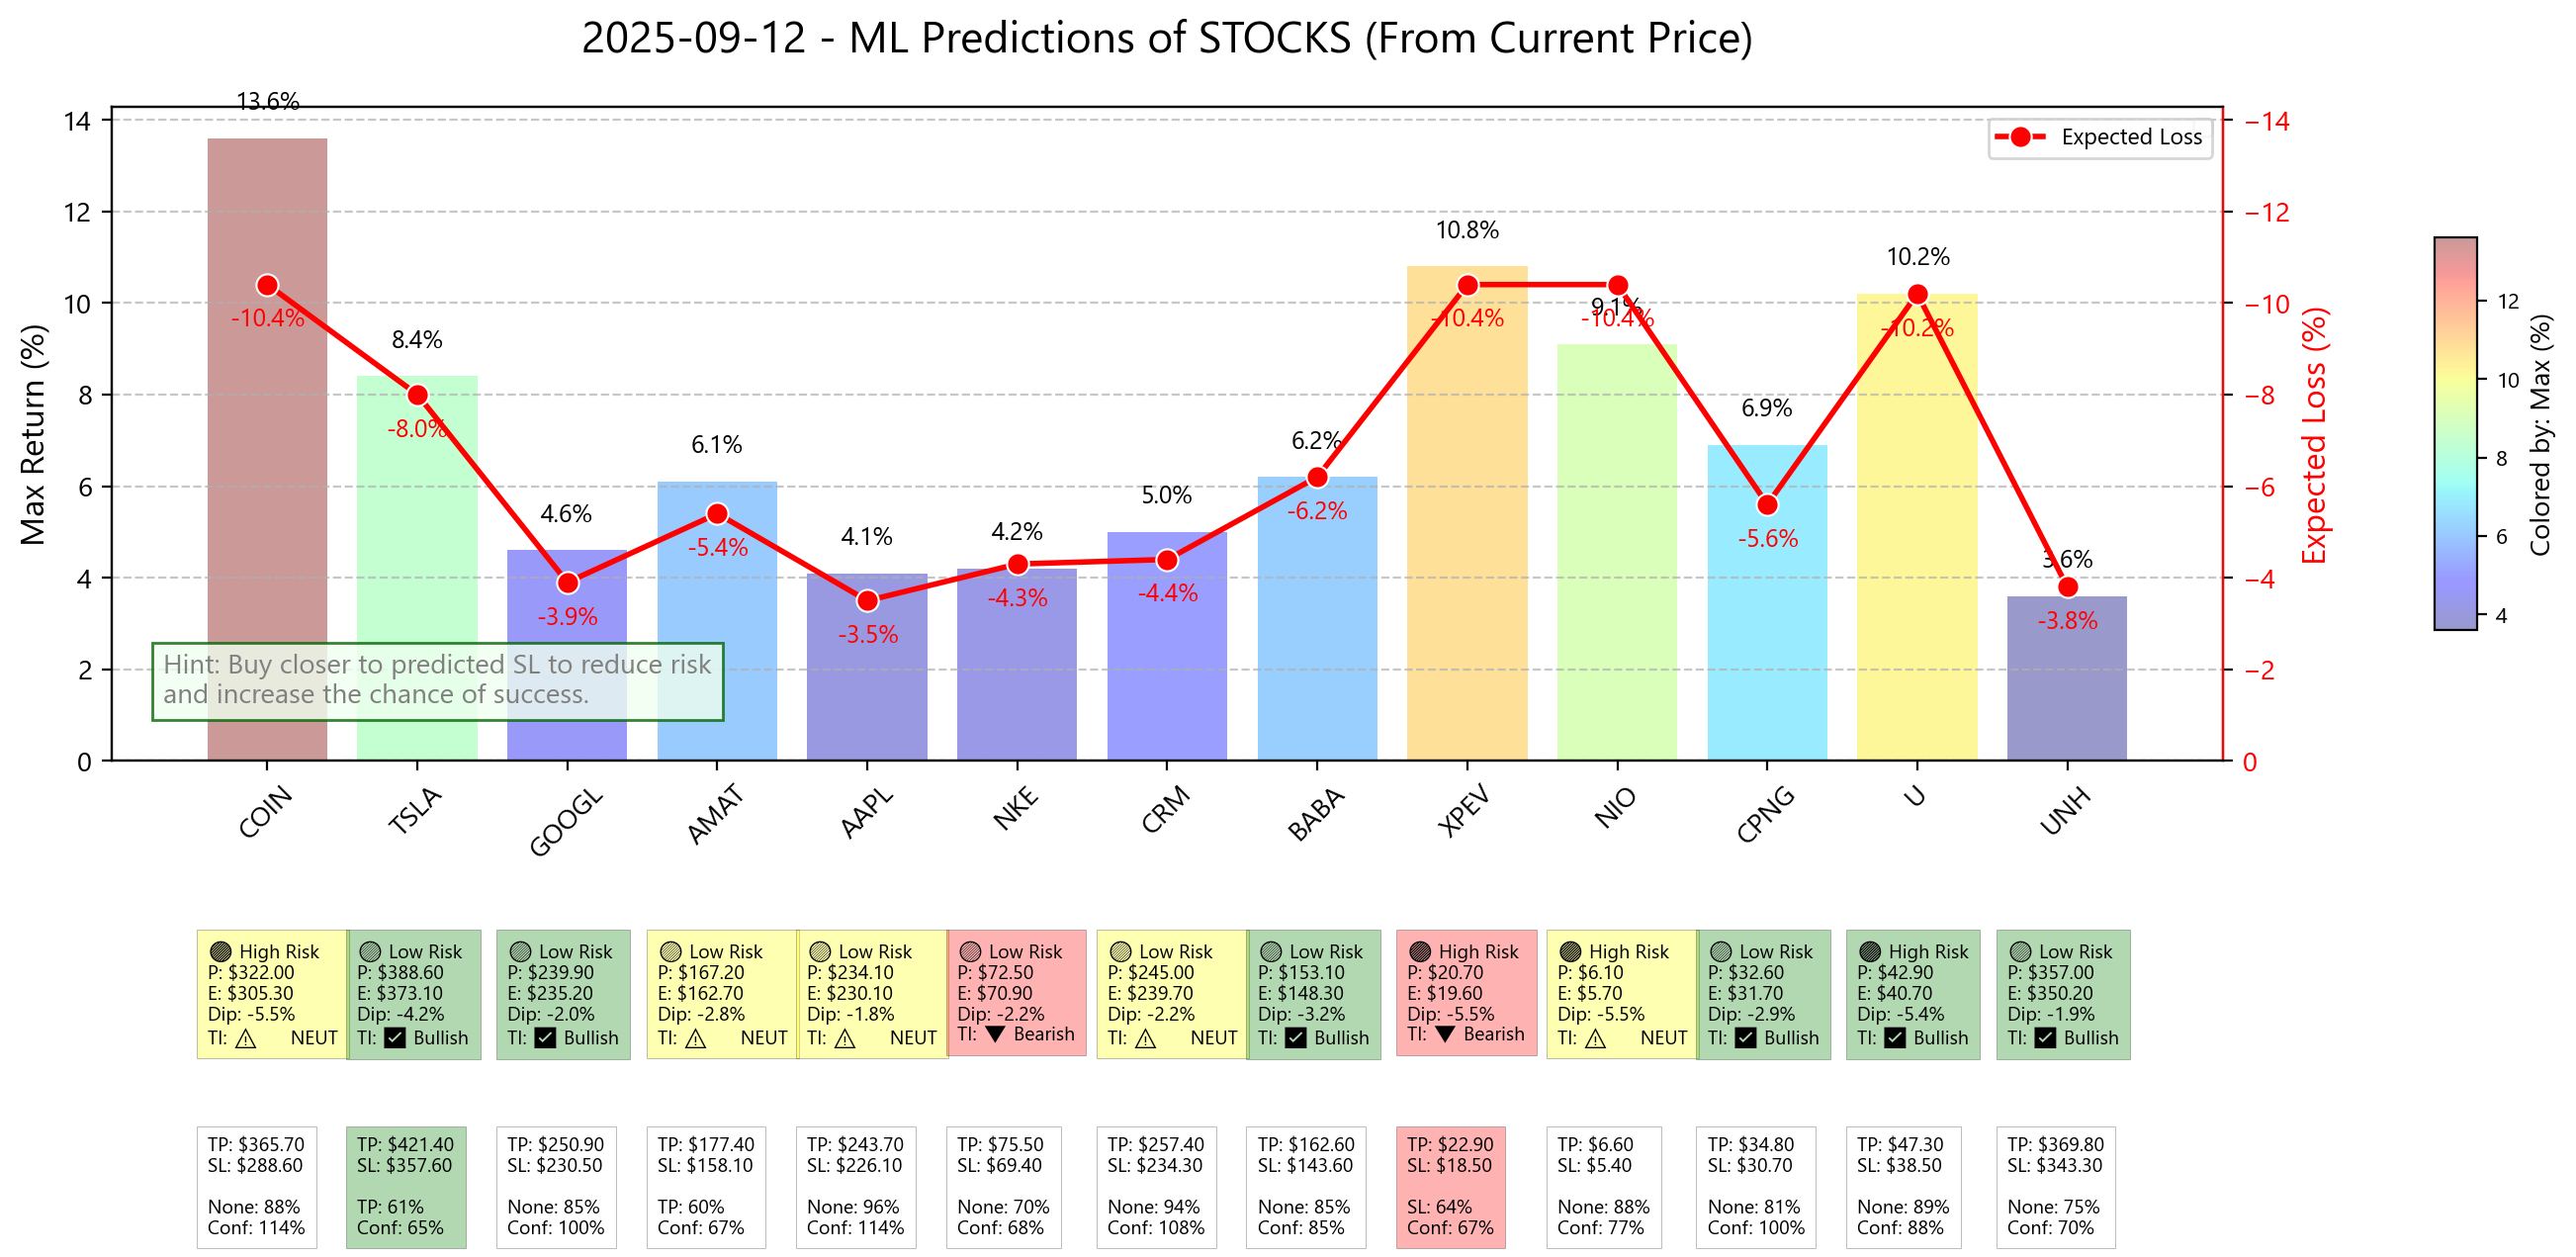

In [7]:
# ✅ PLOT PREDICTIONS

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

df_plot = df_results
#df_plot = df_plot.sort_values(by="Max (%)", ascending=False)
max_vals = df_plot["Max (%)"].to_numpy()
norm = mcolors.Normalize(vmin=min(max_vals), vmax=max(max_vals))
cmap = cm.jet #Inverse of spectral
custom_colors = cmap(norm(max_vals))

fig, ax1 = plt.subplots(figsize=(12, 6), zorder=1, dpi=200)
cax = inset_axes(ax1, width="2%", height="60%", loc='center right',
                 bbox_to_anchor=(0.12, 0., 1, 1),
                 bbox_transform=ax1.transAxes,
                 borderpad=0)

# Main bar plot
ax1.bar(df_plot["Ticker"], max_vals, color=custom_colors, alpha = 0.4)
ax1.set_ylabel('Max Return (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add colorbar at the right of the plot
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical', label="Colored by: Max (%)", alpha = 0.4)
cbar.ax.tick_params(labelsize=8)

# Secondary axis for loss line
ax2 = ax1.twinx()
sns.lineplot(x="Ticker", y="Loss (%)", data=df_plot, color='red', marker='o',
             ax=ax2, linewidth=2, markersize=8, label='Expected Loss')
ax2.set_ylabel('Expected Loss (%)', fontsize=12, color='red')

combined_min = min(ax1.get_ylim()[0], -ax2.get_ylim()[1])
combined_max = max(ax1.get_ylim()[1], -ax2.get_ylim()[0])
ax1.set_ylim(combined_min, combined_max)
ax2.set_ylim(-combined_max, -combined_min)
ax2.spines['right'].set_color('red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.invert_yaxis()
ax1.legend(fontsize='small')
ax2.legend(fontsize='small') 

# --- ANNOTATIONS ALIGNED BELOW X-TICK LABELS ---
x_ticks = ax1.get_xticks()
for i, (_, row) in enumerate(df_plot.iterrows()):
    # Color assignment for signal types
    fcolor = (
        'green' if row.Signal == "TI: ✅ Bullish"
        else 'red' if row.Signal == "TI: 🔻 Bearish"
        else 'yellow'
    )
    ProbColor = 'green' if (row.Signal == "TI: ✅ Bullish" and row.Confidence > 40 and str(row.Will_Hit).split()[0] == 'TP') else 'white'

    if row.Signal == "TI: ✅ Bullish" and row.Confidence > 50 and str(row.Will_Hit).split()[0] == 'TP':
        ProbColor = 'green'
    elif row.Signal == "TI: 🔻 Bearish" and row.Confidence > 50 and str(row.Will_Hit).split()[0] == 'SL':
        ProbColor = 'red'
    else:
        ProbColor = 'white'

    # Top annotations (unchanged)
    ax1.text(i, row["Max (%)"] + 0.5, f'{row["Max (%)"]:.1f}%',
             ha='center', va='bottom', fontsize=9)
    ax2.text(i, row["Loss (%)"] + 0.5, f'{row["Loss (%)"]:.1f}%',
             ha='center', va='top', color='red', fontsize=9)

    # Bottom annotations: align with x-tick, just below tick label
    x_tick = x_ticks[i]
    x_offset = -0.4 # to fix x-shift if colorbar is added, else put this to zero.
    y_offset1 = -0.275  # Adjust as needed for your plot
    y_offset2 = -0.575  # Stagger if two boxes per tick

    ax1.text(
        x_tick+x_offset, y_offset1,
        f'{row["Risk"]}\nP: ${row["Price"]:.2f}\nE: ${row["Entry"]:.2f}\nDip: {row["Dip%"]:.1f}%\n{row["Signal"]}',
        ha='left', va='top', fontsize=7, fontname='Segoe UI Emoji',
        bbox=dict(facecolor=fcolor, alpha=0.3, linewidth=0.3),
        transform=ax1.get_xaxis_transform(),
        multialignment='left',
        clip_on=False
    )

    ax1.text(
        x_tick + x_offset, y_offset2,
        f'TP: ${row["TP"]:.2f}\nSL: ${row["SL"]:.2f}\n\n{str(row.Will_Hit).split()[0]}: {row.Hit_Prob:.0f}%\nConf: {row.Confidence:.0f}%',
        ha='left', va='top', fontsize=7, fontname='Segoe UI Emoji',
        bbox=dict(facecolor=ProbColor, alpha=0.3, linewidth=0.3),
        transform=ax1.get_xaxis_transform(),
        clip_on=False
    )


# Strategic hint box
textbox = AnchoredText(
    "Hint: Buy closer to predicted SL to reduce risk\nand increase the chance of success.",
    loc='lower left',
    frameon=True,
    borderpad=1.5,
    prop=dict(size=10, color='gray', weight='bold')
)
ax1.add_artist(textbox)
textbox.set_clip_on(True)
textbox.set_in_layout(True)
textbox.set_zorder(100)
textbox.patch.set_facecolor('honeydew')
textbox.patch.set_edgecolor('darkgreen')
textbox.patch.set_alpha(0.8)

# Space management
plt.title(f'{today} - ML Predictions of {isStockCrypto} (From Current Price)', fontsize=16, color='black', pad=20)
plt.tight_layout()
plt.subplots_adjust(bottom=0.35)  # Increase if needed for annotation visibility

# Save and show
fname = f'{today}_ML_PNL_Multi{isStockCrypto}.png'
fpath = os.path.join(path, fname)
plt.savefig(fpath, bbox_inches='tight', dpi=300)
plt.show()


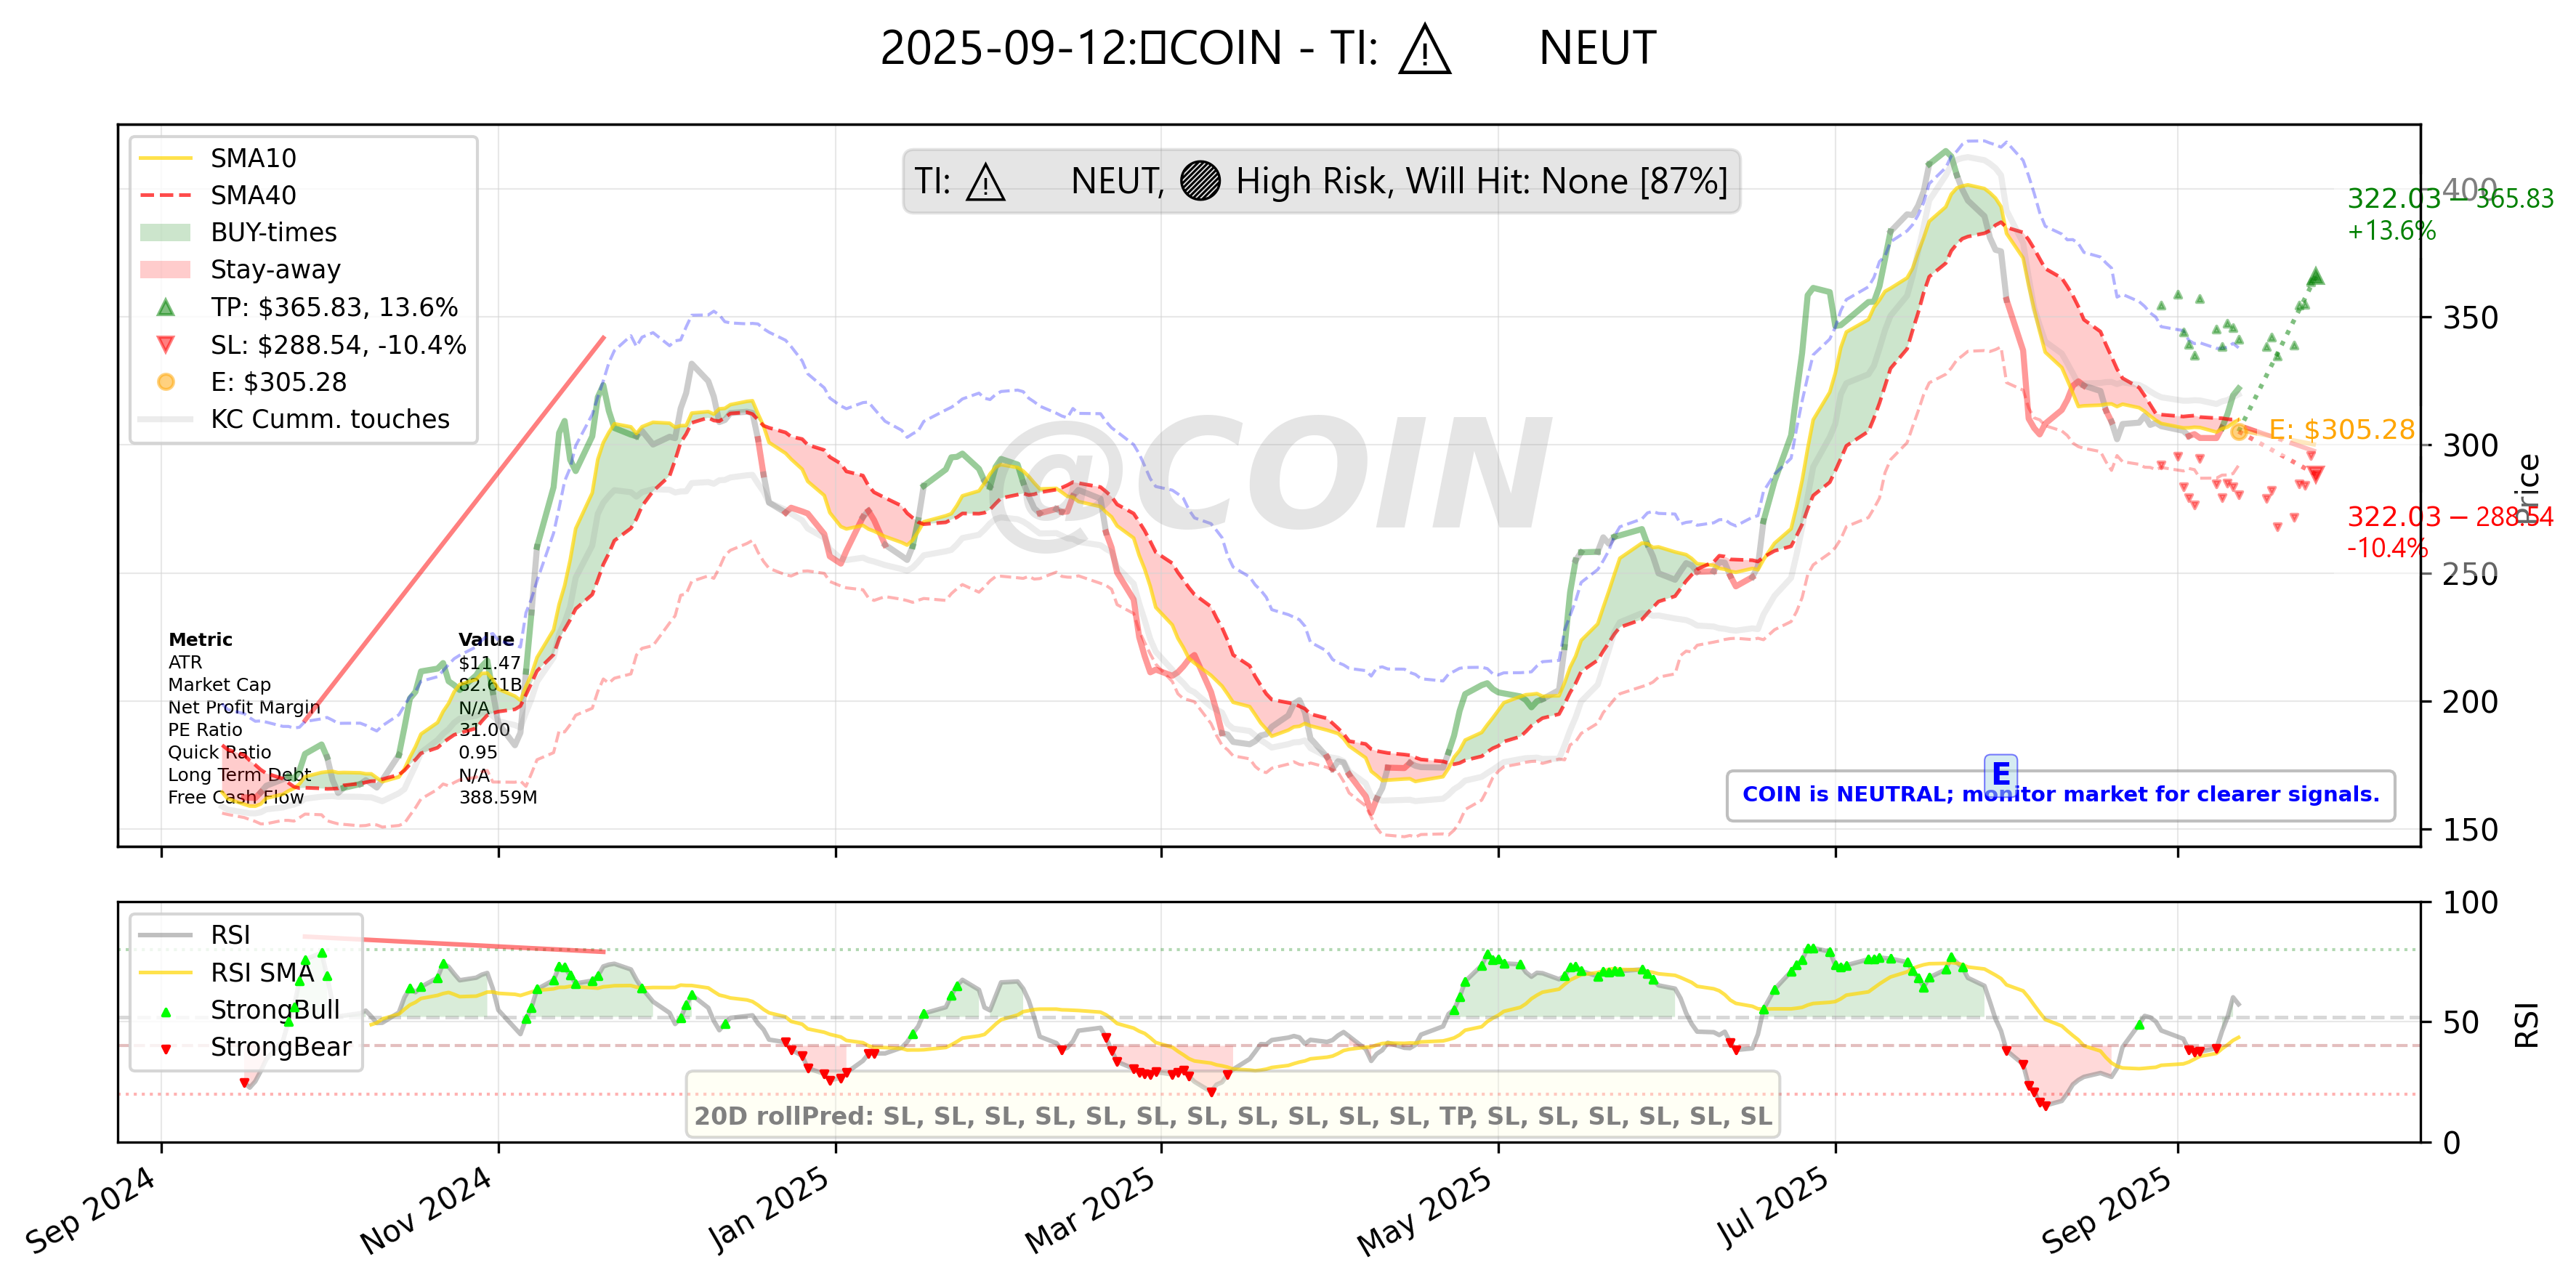

==== Market Technical Summary for COIN ====
Trend: SMA1 (309.86) is above SMA2 (309.77) → Market is bullish.
Momentum: RSI = 51.6 (above its 20-day average of 43.5).
Price: $322.03 is 3.93% above SMA1.

Trend Strength: Strong Bull: No, Strong Bear: No.

Model Signal: TI: ⚠️ NEUT | Expected Gain: +13.6% ($365.83), Loss: -10.4% ($288.54) | Hit Probability: 87.6%.


COIN is NEUTRAL; monitor market for clearer signals.

20D rollPred: SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, TP, SL, SL, SL, SL, SL, SL


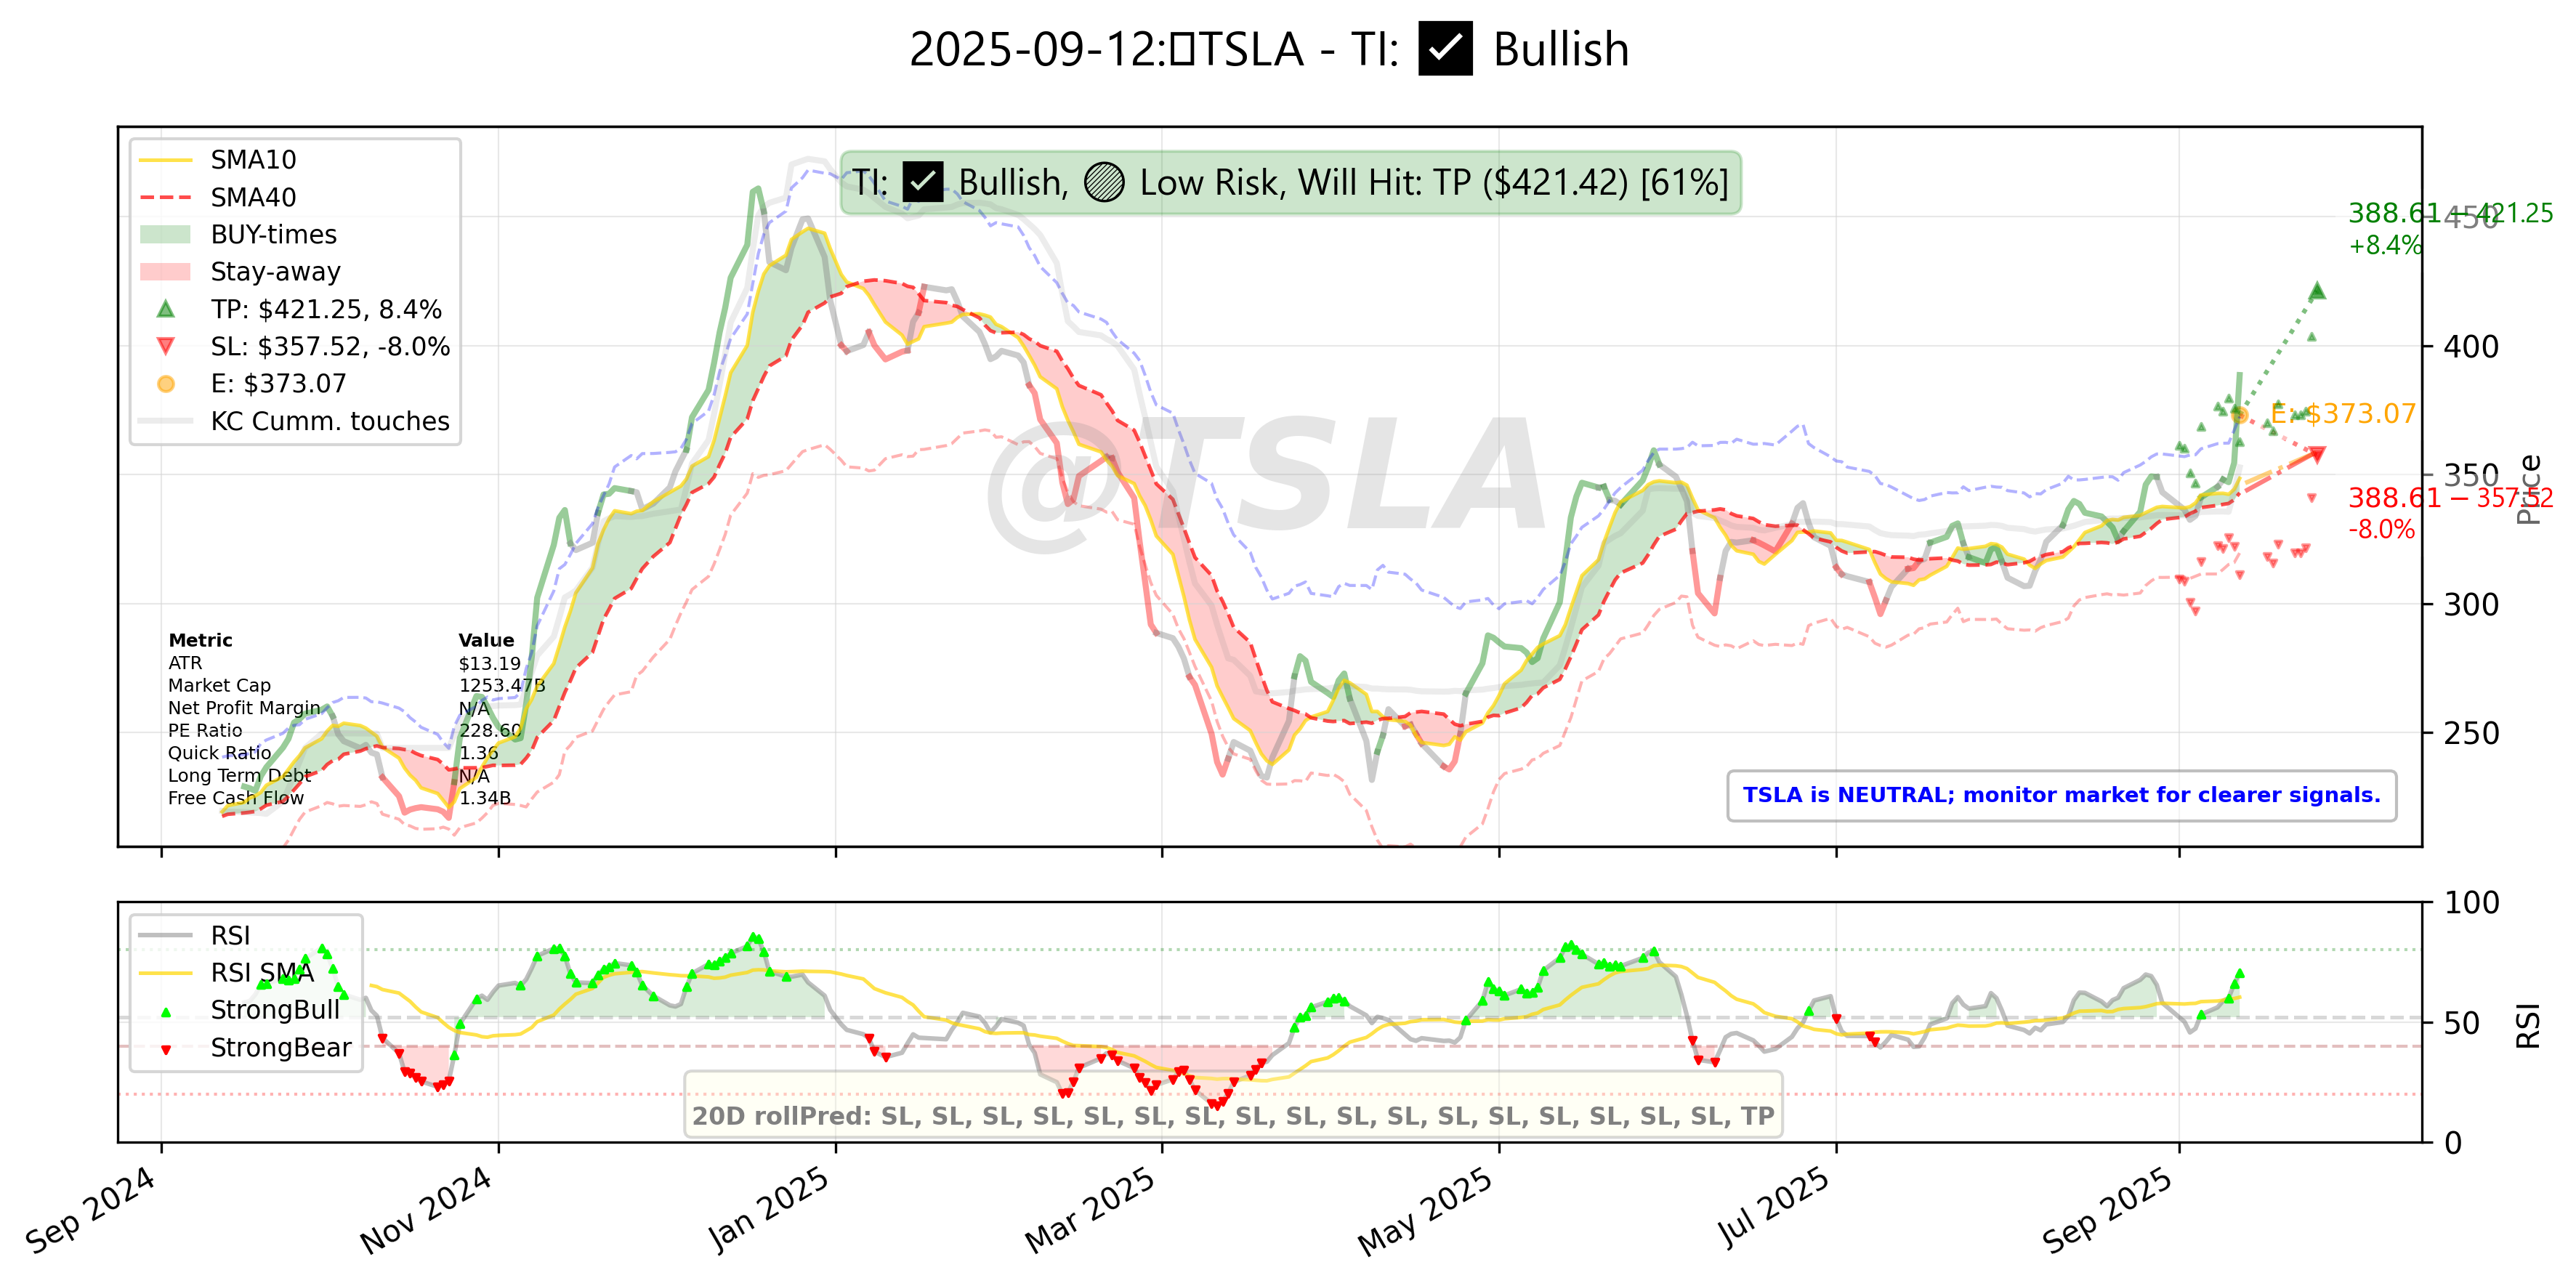

==== Market Technical Summary for TSLA ====
Trend: SMA1 (348.53) is above SMA2 (342.91) → Market is bullish.
Momentum: RSI = 73.8 (above its 20-day average of 60.3).
Price: $388.61 is 11.50% above SMA1.

Trend Strength: Strong Bull: Yes, Strong Bear: No.

Model Signal: TI: ✅ Bullish | Expected Gain: +8.4% ($421.25), Loss: -8.0% ($357.52) | Hit Probability: 61.0%.


TSLA is NEUTRAL; monitor market for clearer signals.

20D rollPred: SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, SL, TP


In [ ]:
# PLOT STOCK TA with Predictions
for ticker in TICKERS:
    _df = dfs.get(ticker)
    if _df is None:
        print(f"Skipping {ticker}: no preloaded data available")
        continue
    plot_single_ticker(ticker, _df, df_results)
    
del_old_files(path, 14)

In [ ]:
# CREATE A PYTHON FILE BACKUP
!jupyter nbconvert --to script FixedProfit_ML_MultiStocksV4.ipynb

## Script Summary and Output Guide

This script implements a **machine-learning assisted technical analysis and price prediction framework** applied to multiple stock and crypto tickers. It uses historical daily price and volume data, enriched with diverse technical indicators and pivot levels to train models that forecast potential trade outcomes.

### What the Script Does

- Downloads historical price and volume data for specified tickers over several years.
- Computes a comprehensive set of technical indicators, including RSI, ADX, ATR, moving averages, Keltner channels, volume-based metrics, candlestick patterns, and custom signals like the exhaustion indicator (proximity to 90-day highs/lows).
- Calculates pivot price levels for support/resistance estimation.
- Labels historical data rows by whether profit targets or stop losses are hit within a forward window.
- Trains three machine learning models per ticker:
  - A classifier predicting if the profit target or stop loss will be hit.
  - A regression model predicting expected return.
  - A regression model predicting expected loss.
- Generates live predictions for each ticker combining model outputs and technical signals to produce:
  - Expected trade direction (bullish, bearish, neutral, exhaustion flagged)
  - Expected profit target (TP) and stop loss (SL) prices
  - Confidence metrics and hit probabilities
- Produces detailed plots per ticker illustrating price action, SMAs, RSI, pivot zones, divergence signals, and model predictions with annotations.
- Outputs a formatted prediction table with colored signals, probabilities, risks, and exhaustion warnings.
- Maintains a rolling record of recent predictions saved to Excel for review or further analysis.

### Output Components

- **Prediction Table:** Displays for each ticker the latest price, TP/SL forecasts, predicted direction (Signal), risk assessment, confidence score, and exhaustion status. Rows are color-coded:
  - Green: Bullish signals with strong confidence and profitable outlook.
  - Red: Bearish or high-risk signals.
  - Yellow: Signals flagged with exhaustion (near 90-day highs/lows).
  - Gray: Neutral or low-confidence signals.
  
- **Price and RSI Plots:**  
  - Price chart with simple moving averages (SMA1, SMA2), Keltner channel boundaries, buy/sell zones marked by colors.
  - RSI plot and its SMA with filled areas marking oversold/overbought regions.
  - Key dates like earnings and annotation of model signals.
  - Trade predictions annotated as markers (TP, SL, Entry).
  - Divergence and double top/bottom patterns visually identified.
  
- **Pivot Levels:** Displayed as horizontal lines representing average pivot support and resistance zones.

### Abbreviations and Terms

- **TP:** Take Profit target price predicted by the model.
- **SL:** Stop Loss price predicted by the model.
- **RSI:** Relative Strength Index, momentum oscillator.
- **SMA1, SMA2:** Short and long simple moving averages used for trend direction.
- **ADX:** Average Directional Index, trend strength indicator.
- **KC:** Keltner Channel lines (Upper_Band, Lower_Band).
- **Prob:** Probability that the predicted event (TP or SL hit) will occur.
- **Confidence:** Combined measure incorporating hit probability and expected return/loss ratio.
- **Exhaustion:** Flag indicating price is near 90-day high or low (“exhausted” condition).
- **Bullish/Bearish/Neutral:** Technical and model signals for potential market direction.

### How to Interpret Outputs

- Use the **prediction table** to quickly identify promising trade opportunities with high confidence and favorable risk profiles.
- Check the **signal colors** to prioritize entries: green for high-conviction bulls, red for bearish warnings, yellow to avoid exhausted setups.
- Review charts to validate signals visually, noting diverging RSI or key pivot levels aligning with model targets.
- Consider the **exhaustion flag** as a caution signal, often meaning reduced trade success probability near major price extremes.
- Combine multiple indicators and model outputs for robust entry and exit timing, managing risk prudently.


In [ ]:
import matplotlib.pyplot as plt

def plot_price_with_hit_labels(df):
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df.index, df['Close'], label='Close Price', color='gray')
    
    bulls = df[df['Bull'] == 1]
    ax.scatter(bulls.index, bulls['Close'], color='green', marker='^', s=5, alpha=0.5, label='Bull Signal')

    bears = df[df['Bear'] == 1]
    ax.scatter(bears.index, bears['Close'], color='red', marker='v', s=5, alpha=0.5, label='Bear Signal')

    none = df[df['Neutral'] == 1]
    ax.scatter(none.index, none['Close'], color='blue', marker='o', s=5, alpha=0.5, label='Neutral Signal')
        
    ax.set_title('Price Chart with Hit Labels')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True)
    plt.show()

plot_price_with_hit_labels(dfs.get('TSLA'))
# Check per row sum of Bull, Bear, Neutral columns
row_sums = df[['Bull', 'Bear', 'Neutral']].sum(axis=1)

# Find rows where conditions overlap or are all zero
invalid_rows = df[row_sums != 1]

if invalid_rows.empty:
    print("Bull, Bear, and Neutral conditions are mutually exclusive and cover all rows.")
else:
    print(f"Found {len(invalid_rows)} rows where Bull, Bear, and Neutral overlap or none is set.")
    print(invalid_rows[['Bull', 'Bear', 'Neutral']])
